In [1]:
import adios4dolfinx
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

from dolfinx.fem.petsc import LinearProblem
from ufl import sqrt, inner, TestFunction, TrialFunction, dot, grad, CellDiameter, dx
from pathlib import Path
from mpi4py import MPI
from dolfinx import mesh, fem, io, plot
from basix.ufl import element


In [2]:
# wind_file = Path("../wind_data/airflow_ipcs.bp")
wind_file = Path("../wind_data/airflow_picard.bp")
domain = adios4dolfinx.read_mesh(wind_file, MPI.COMM_WORLD)

topology, cell_type, geom = plot.vtk_mesh(domain) 
grid = pv.UnstructuredGrid(topology, cell_type, geom)

dom_cell = domain.basix_cell()
V_wind = fem.functionspace(domain, element("Lagrange", dom_cell, 1, shape=(domain.topology.dim,)))

beta = fem.Function(V_wind)
adios4dolfinx.read_function(wind_file, beta, name="velocity_H1")

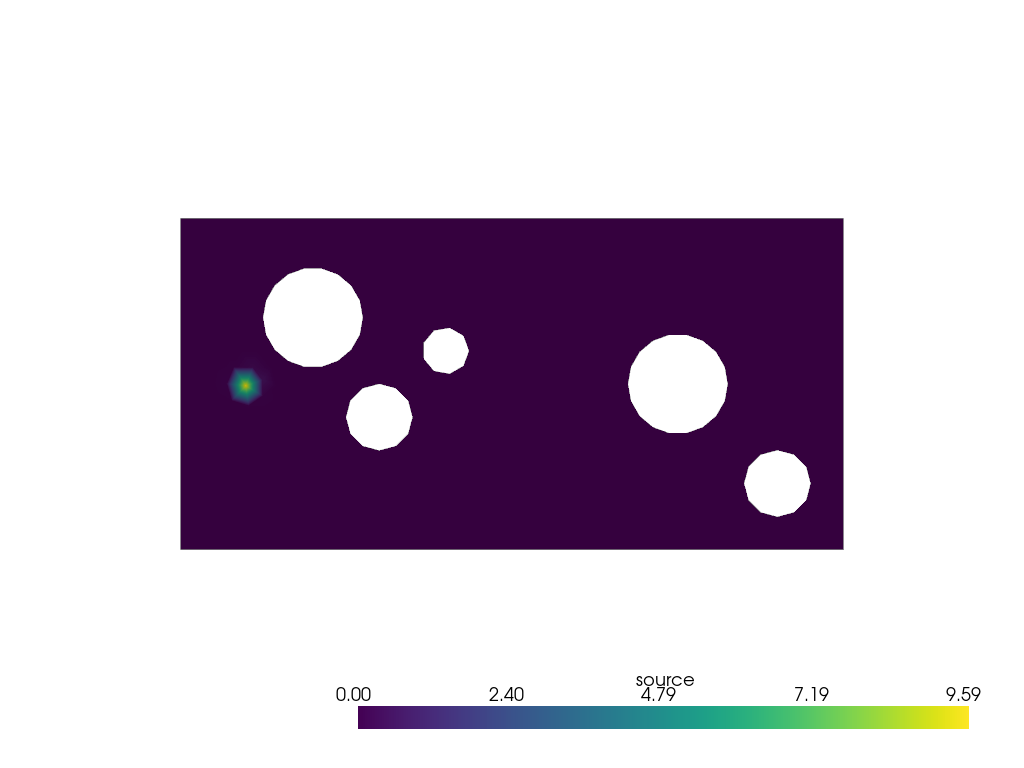

In [3]:
coords = domain.geometry.x
x_min, y_min = np.min(coords[:, 0]), np.min(coords[:, 1])
x_max, y_max = np.max(coords[:, 0]), np.max(coords[:, 1])

x_lim = x_max - x_min
y_lim = y_max - y_min

x0, y0 = 0.1 * x_lim, 0.5 * y_lim
sigma_x, sigma_y = 0.01 * x_lim, 0.01 * x_lim

# Source term as 2D-Gauss
def source_term(x: np.ndarray):
    return 10.0 * np.exp(-((x[0] - x0)**2 / (2 * sigma_x**2) + (x[1] - y0)**2 / (2 * sigma_y**2)))

V_scalar = fem.functionspace(domain, element("CG", domain.basix_cell(), 1))
f_true = fem.Function(V_scalar)
f_true.interpolate(source_term)

# Boundary condition (zero dirichlet)
def boundary(x):
    return np.isclose(x[0], x_min)

u_zero = fem.Constant(domain, 0.0)
bc_zero = fem.dirichletbc(u_zero, fem.locate_dofs_geometrical(V_scalar, boundary), V_scalar)

#Plot
grid.point_data["source"] = f_true.x.array
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="source", cmap="viridis", show_edges=False)
plotter.view_xy()
plotter.show()

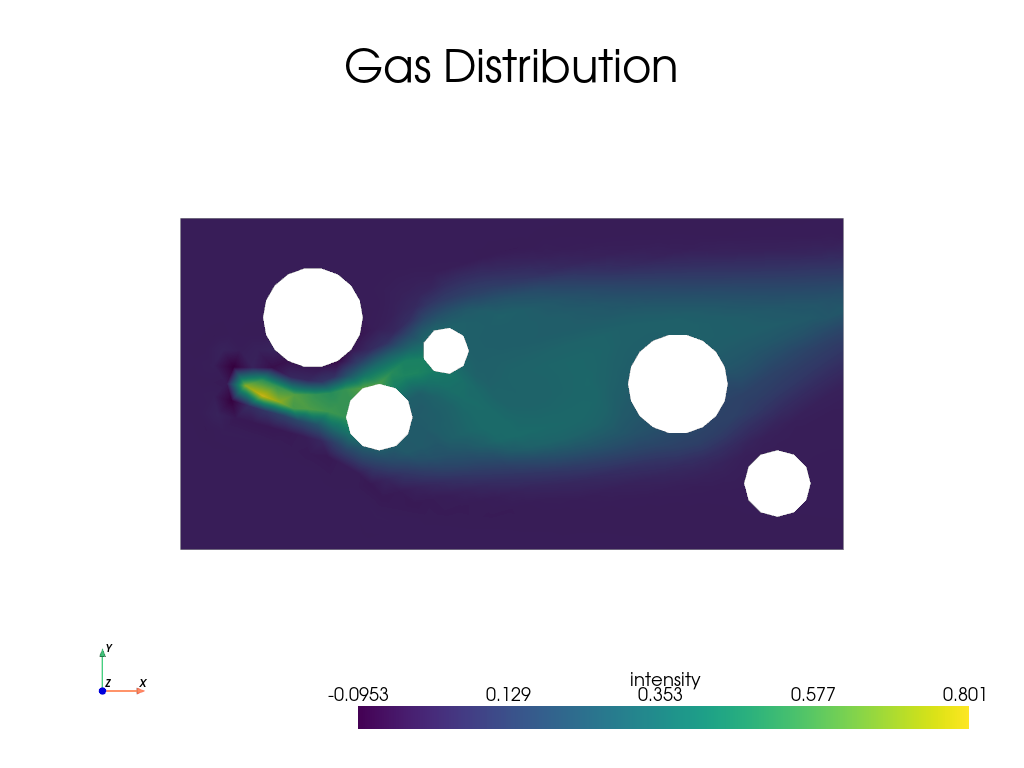

In [4]:
# Forward simulation
D_phys = D_phys = fem.Constant(domain, 0.001)
U_char = sqrt(dot(beta, beta))
L_char = fem.Constant(domain, x_lim)
h = CellDiameter(domain)
Pe = U_char * L_char / D_phys
nb = sqrt(inner(beta, beta))

tau = 0.5 * h * pow(4.0 / (Pe*h) + 2.0 * nb, -1.0)

v = TestFunction(V_scalar)
u = TrialFunction(V_scalar)
f = fem.Function(V_scalar)

# For true solution: set f to the value of the true source
f = f_true

# SUPG version for linear and bilinear form
a = D_phys * inner(grad(u), grad(v)) * dx + inner(beta, grad(u)) * v * dx + \
         tau * inner(beta, grad(u)) * inner(beta, grad(v)) * dx
L = f * v * dx + tau * f * inner(beta, grad(v)) * dx

forward_problem = LinearProblem(a, L, [bc_zero])

c_true = forward_problem.solve()

# Plot
grid.point_data["intensity"] = c_true.x.array 
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="intensity", cmap="viridis", show_edges=False)
plotter.add_title("Gas Distribution")
plotter.view_xy()
plotter.show_axes()
#plotter.show_grid()

plotter.show()


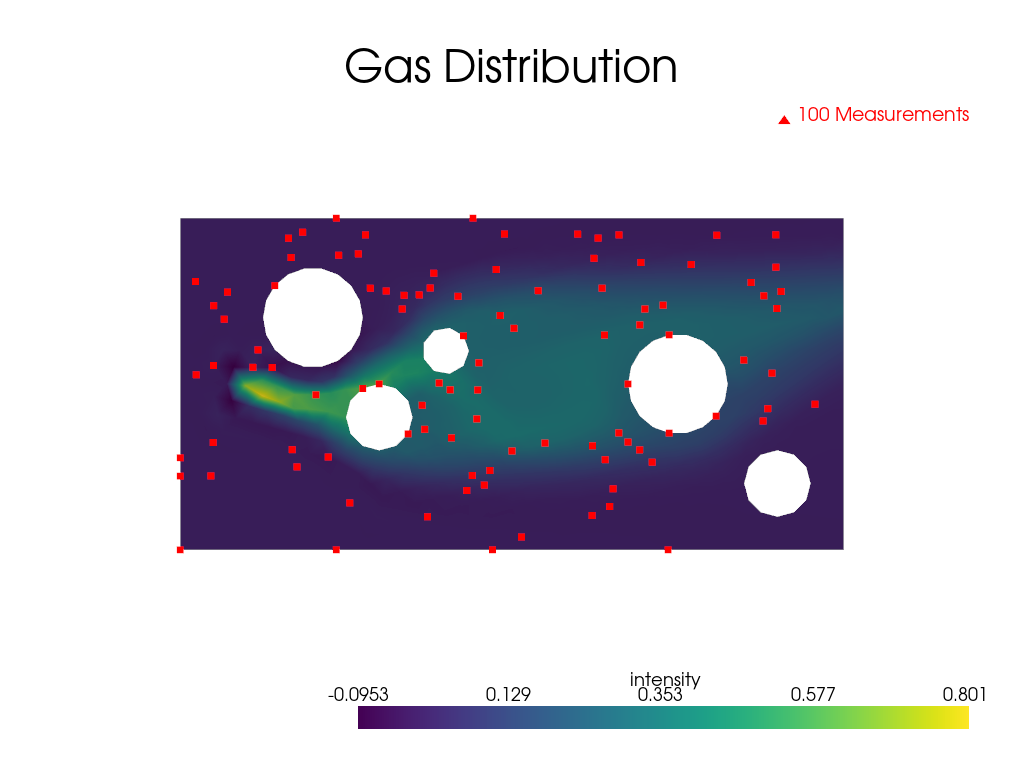

In [5]:
# Select values from c in m
n = len(c_true.x.array)
n_measurements = 100 # int(0.01 * n)

# # random distribution
np.random.seed(3) # Good vals: 9
m_ids = np.random.choice(np.arange(n), size=n_measurements, replace=False) # random distribution

m = c_true.x.array[m_ids]

# Plot
grid.point_data["intensity"] = c_true.x.array 
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="intensity", cmap="viridis", show_edges=False)
selected_points = grid.points[m_ids]

plotter.add_points(
    selected_points,
    color="red",        
    point_size=7,
    label=f"{n_measurements} Measurements")
plotter.add_title("Gas Distribution")
plotter.view_xy()
#plotter.show_grid()
plotter.add_legend()
plotter.show()



In [6]:
# Inverse Problem

lagrange_mult = TrialFunction(V_scalar)
residual = fem.Function(V_scalar)
residual.x.array[:] = 0.0

a_adj = D_phys * inner(grad(v), grad(lagrange_mult)) * dx \
        + inner(beta, grad(v)) * lagrange_mult * dx \
        + tau * inner(beta, grad(v)) * inner(beta, grad(lagrange_mult)) * dx
L_adj = inner(residual, v) * dx \
        + tau * inner(beta, grad(v)) * residual * dx

adjoint_problem = LinearProblem(a_adj, L_adj, [bc_zero])

it   0 mis=3.208e+00 ||grad||=6.133e+00
it  10 mis=6.115e-01 ||grad||=3.399e-01
it  20 mis=2.185e-01 ||grad||=7.053e-01
it  30 mis=1.853e-01 ||grad||=3.811e-01
it  40 mis=1.738e-01 ||grad||=2.026e-01
it  50 mis=1.687e-01 ||grad||=1.657e-01
it  60 mis=1.641e-01 ||grad||=1.477e-01
it  70 mis=1.598e-01 ||grad||=1.532e-01
it  80 mis=1.549e-01 ||grad||=1.982e-01
it  90 mis=1.510e-01 ||grad||=1.992e-01
it 100 mis=1.473e-01 ||grad||=1.829e-01
it 110 mis=1.433e-01 ||grad||=1.414e-01
it 120 mis=1.401e-01 ||grad||=2.046e-01
it 130 mis=1.361e-01 ||grad||=1.392e-01
it 140 mis=1.322e-01 ||grad||=1.435e-01
it 150 mis=1.292e-01 ||grad||=1.678e-01
it 160 mis=1.263e-01 ||grad||=1.501e-01
it 170 mis=1.238e-01 ||grad||=1.540e-01
it 180 mis=1.210e-01 ||grad||=1.722e-01
it 190 mis=1.183e-01 ||grad||=1.472e-01
it 199 mis=1.158e-01 ||grad||=9.052e-02


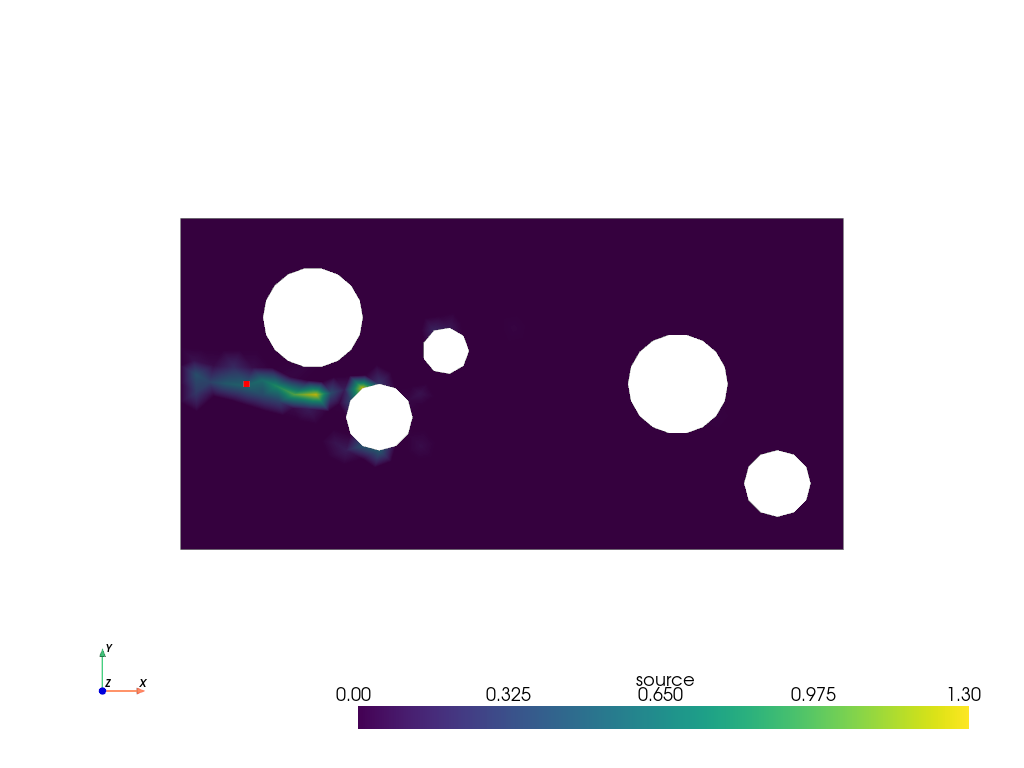

Max source estimate: 1.2995057497919522


In [7]:
# Iteration loop old

m = c_true.x.array[m_ids]
f.x.array[:] = 0.0

max_it = 200
gamma = 1e-2
alpha0 = 10.0
tol_rel = 1e-7
tol_grad = 1e-8
c_arm = 1e-3
rho = 0.5
alpha_hist = []
misfit_hist = []

def compute_misfit(c_func: fem.Function, f_func: fem.Function):
    res = c_func.x.array[m_ids] - m
    # return 0.5 * np.dot(res, res) + 0.5 * gamma * np.dot(f_func.x.array, f_func.x.array) # L2
    return np.dot(res, res) + 0.5 * gamma * np.sum(np.abs(f_func.x.array)) # L1

for it in range(max_it):
    # forward
    c = forward_problem.solve()

    # Current misfit
    mis = compute_misfit(c, f)

    # Set adjoint rhs setzen und lösen
    residual.x.array[:] = 0.0
    residual.x.array[m_ids] = -(c.x.array[m_ids] - m)
    adj = adjoint_problem.solve()

    # Gradient
    # gradJ = -adj.x.array + gamma * f.x.array # L2
    gradJ = -adj.x.array # L1 smooth gradient (without regularization term)
    grad_norm = np.linalg.norm(gradJ) 

    alpha = alpha0
    f_old = f.x.array.copy()

    # Armijo search
    while True:
        # L1
        y = f_old - alpha * gradJ
        f.x.array[:] = np.sign(y) * np.maximum(np.abs(y) - alpha * gamma, 0.0)
        # L2
        # f.x.array[:] = f_old - alpha * gradJ
        
        c_trial = forward_problem.solve()
        mis_trial = compute_misfit(c_trial, f)

        if mis_trial <= mis - c_arm * alpha * grad_norm**2:
            break
        alpha *= rho
    if alpha < 1e-14:
        if grad_norm > tol_grad:
            print("Alpha too small.")
    
    mis_new = compute_misfit(c_trial, f)
    misfit_hist.append(mis_new)
    alpha_hist.append(alpha)

    if it % 10 == 0 or it == max_it-1:
        print(f"it {it:3d} mis={mis:.3e} ||grad||={grad_norm:.3e}")

    # Convergence
    if it > 1:
        rel_change = abs(misfit_hist[-2] - misfit_hist[-1]) / max(1e-12, misfit_hist[-2])
        if rel_change < tol_rel or grad_norm < tol_grad:
            print(f"Stopped at it {it}, rel. change={rel_change:.3e}")
            break
# alpha_hist

# Visualize result
grid.point_data["source"] = f.x.array 
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="source", cmap="viridis", show_edges=False)

true_source_location = np.array([x0, y0, 0])
marker_mesh = pv.PolyData(true_source_location)
plotter.add_mesh(marker_mesh,
                 color='red',  
                 label="True Source Location",
                 point_size=6,
                 opacity=1)
# plotter.add_legend()

plotter.view_xy()
plotter.show_axes()
plotter.show()
print(f"Max source estimate: {max(f.x.array)}")

It   0  mis=1.397e+00  ||grad||=5.870e+00  α=7.81e-02
It  20  mis=8.655e-02  ||grad||=1.299e-01  α=3.12e-01
It  40  mis=3.984e-02  ||grad||=1.415e-01  α=7.81e-02
It  60  mis=3.174e-02  ||grad||=1.002e-01  α=7.81e-02
It  80  mis=2.963e-02  ||grad||=6.847e-02  α=7.81e-02
It 100  mis=2.842e-02  ||grad||=4.701e-02  α=7.81e-02
It 120  mis=2.764e-02  ||grad||=3.236e-02  α=7.81e-02
It 140  mis=2.712e-02  ||grad||=4.642e-02  α=7.81e-02
It 160  mis=2.673e-02  ||grad||=3.183e-02  α=7.81e-02
It 180  mis=2.645e-02  ||grad||=2.552e-02  α=1.56e-01
It 200  mis=2.626e-02  ||grad||=1.661e-02  α=7.81e-02
It 220  mis=2.613e-02  ||grad||=2.362e-02  α=7.81e-02
It 240  mis=2.602e-02  ||grad||=1.577e-02  α=7.81e-02
It 249  mis=2.598e-02  ||grad||=3.621e-03  α=3.12e-01


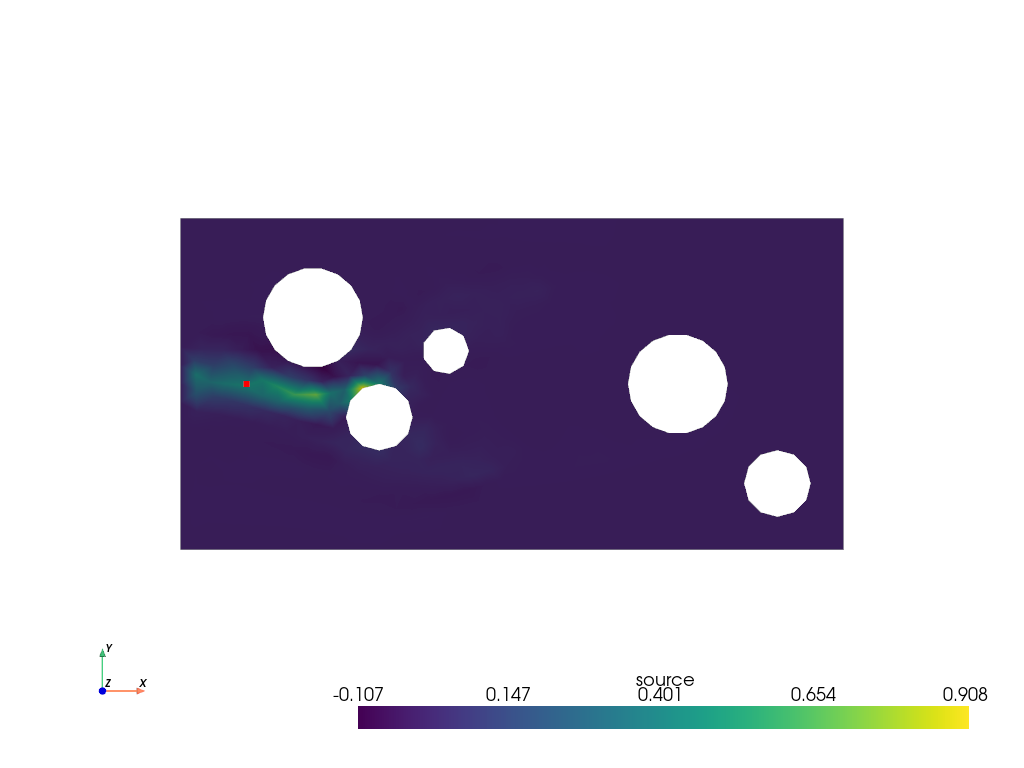

Max source estimate: 0.9079229703889143


In [8]:
# -----------------------------
# Setup
# -----------------------------
m = c_true.x.array[m_ids]
f.x.array[:] = 0.0

max_it = 250
gamma = 1e-2 
alpha0 = 10.0
tol_rel = 1e-7
tol_grad = 1e-8
c_arm = 1e-3
rho = 0.5

alpha_hist = []
misfit_hist = []

# -----------------------------
# Define loss functions
# -----------------------------
def misfit_logcosh(c_func, f_func):
    r = c_func.x.array[m_ids] - m
    data_term = np.sum(np.log(np.cosh(r)))
    reg_term = 0.5 * gamma * np.dot(f_func.x.array, f_func.x.array)
    return data_term + reg_term

def dJ_dc_logcosh(r):
    return np.tanh(r)

# -----------------------------
# Assign loss
# -----------------------------
misfit_fn = misfit_logcosh
dJ_dc_fn = dJ_dc_logcosh

# -----------------------------
# Iterative optimization
# -----------------------------
for it in range(max_it):
    # Forward solve
    c = forward_problem.solve()
    r = c.x.array[m_ids] - m

    # Misfit
    misfit = misfit_fn(c, f)

    # Adjoint
    residual.x.array[:] = 0.0
    residual.x.array[m_ids] = -dJ_dc_fn(r)
    adj = adjoint_problem.solve()

    # Gradient
    gradJ = -adj.x.array + gamma * f.x.array
    grad_norm = np.linalg.norm(gradJ)

    # Armijo line search
    alpha = alpha0
    f_old = f.x.array.copy()
    while True:
        f.x.array[:] = f_old - alpha * gradJ

        c_trial = forward_problem.solve()
        misfit_trial = misfit_fn(c_trial, f)

        if misfit_trial <= misfit - c_arm * alpha * grad_norm**2:
            break
        alpha *= rho
        if alpha < 1e-14:
            break

    misfit_hist.append(misfit_trial)
    alpha_hist.append(alpha)

    if it % 20 == 0 or it == max_it - 1:
        print(f"It {it:3d}  mis={misfit:.3e}  ||grad||={grad_norm:.3e}  α={alpha:.2e}")

    # Convergence
    if it > 1:
        rel_change = abs(misfit_hist[-2] - misfit_hist[-1]) / max(1e-12, misfit_hist[-2])
        if rel_change < tol_rel or grad_norm < tol_grad:
            print(f"Stopped at it {it}, rel. change={rel_change:.3e}")
            break

# -----------------------------
# Visualization
# -----------------------------
grid.point_data["source"] = f.x.array
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="source", cmap="viridis", show_edges=False)
true_source_location = np.array([x0, y0, 0])
marker_mesh = pv.PolyData(true_source_location)
plotter.add_mesh(marker_mesh, color='red', point_size=6, opacity=1)
plotter.view_xy()
plotter.show_axes()
plotter.show()
print(f"Max source estimate: {max(f.x.array)}")